In [1]:
import sys

print(sys.executable)

c:\Users\Hp\AppData\Local\Programs\Python\Python311\python.exe


In [1]:
import pandas as pd
import numpy as np

print(pd.__version__)
print(np.__version__)

2.2.2
1.26.4


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
import sys
print(sys.executable)

c:\Users\Hp\AppData\Local\Programs\Python\Python311\python.exe


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv(
    "../data/processed/ethiopia_fi_enriched_dataset.csv"
)

df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [6]:
df.shape

(48, 34)

In [7]:
df["record_type"].value_counts()

record_type
observation    30
event          15
target          3
Name: count, dtype: int64

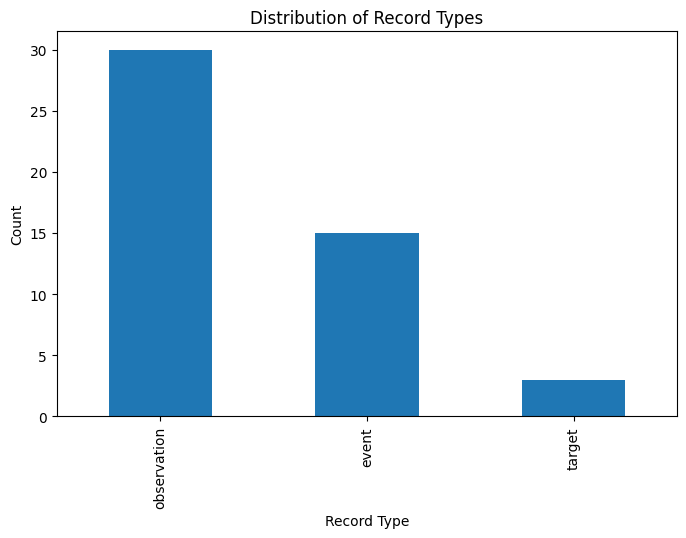

In [9]:
plt.figure(figsize=(8,5))

df["record_type"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Record Types")
plt.xlabel("Record Type")
plt.ylabel("Count")

plt.show()

In [10]:
df["pillar"].value_counts()

pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

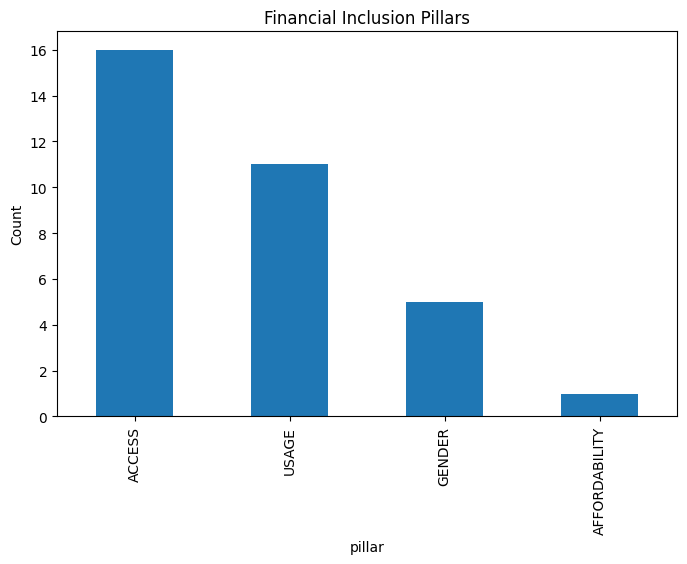

In [11]:
plt.figure(figsize=(8,5))

df["pillar"].value_counts().plot(
    kind="bar"
)

plt.title("Financial Inclusion Pillars")
plt.ylabel("Count")

plt.show()

In [12]:
df["source_type"].value_counts()

source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

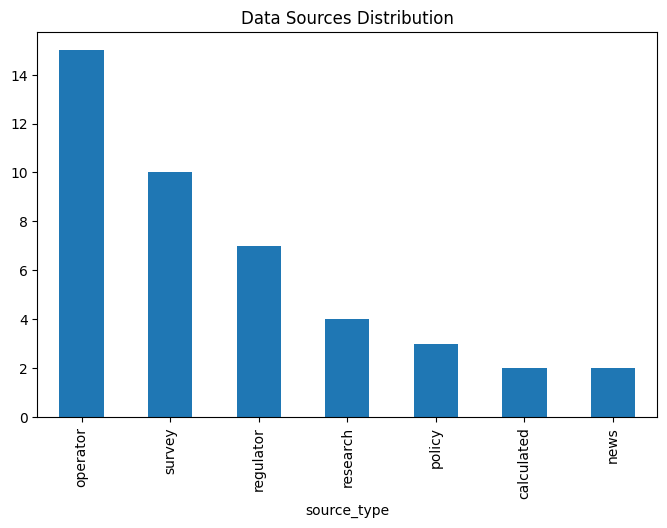

In [13]:
plt.figure(figsize=(8,5))

df["source_type"].value_counts().plot(
    kind="bar"
)

plt.title("Data Sources Distribution")

plt.show()

In [14]:
df["confidence"].value_counts()

confidence
high      43
medium     5
Name: count, dtype: int64

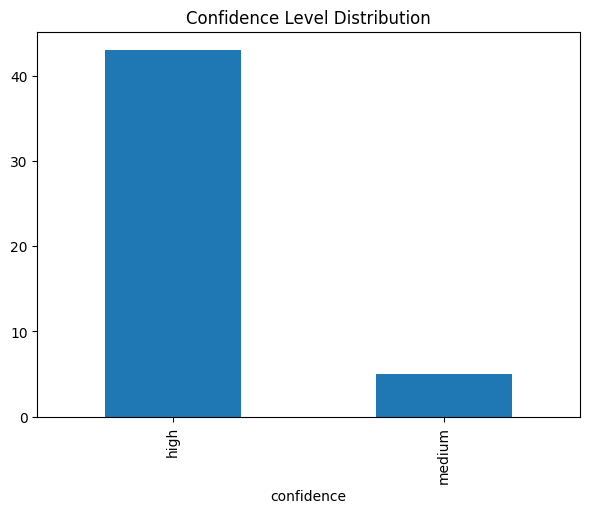

In [15]:
plt.figure(figsize=(7,5))

df["confidence"].value_counts().plot(
    kind="bar"
)

plt.title("Confidence Level Distribution")

plt.show()

In [16]:
missing = df.isnull().sum()

missing.sort_values(
    ascending=False
).head(15)

region               48
related_indicator    48
evidence_basis       48
lag_months           48
impact_estimate      48
impact_magnitude     48
impact_direction     48
relationship_type    48
notes                48
period_start         38
period_end           38
category             33
value_text           33
collection_date      33
source_url           17
dtype: int64

In [17]:
missing_percentage = (
    df.isnull().mean()*100
)

missing_percentage.sort_values(
    ascending=False
).head(15)

region               100.000000
related_indicator    100.000000
evidence_basis       100.000000
lag_months           100.000000
impact_estimate      100.000000
impact_magnitude     100.000000
impact_direction     100.000000
relationship_type    100.000000
notes                100.000000
period_start          79.166667
period_end            79.166667
category              68.750000
value_text            68.750000
collection_date       68.750000
source_url            35.416667
dtype: float64

In [18]:
df["observation_date"] = pd.to_datetime(
    df["observation_date"]
)

In [19]:
df["year"] = df["observation_date"].dt.year

In [20]:
coverage = df.groupby(
[
"year",
"indicator_code"
]
).size().reset_index(name="count")


coverage.head()

,year,indicator_code,count
0,2014,ACC_OWNERSHIP,1
1,2017,ACC_OWNERSHIP,1
2,2021,ACC_MM_ACCOUNT,1
3,2021,ACC_OWNERSHIP,3
4,2021,EVT_NFIS2,1


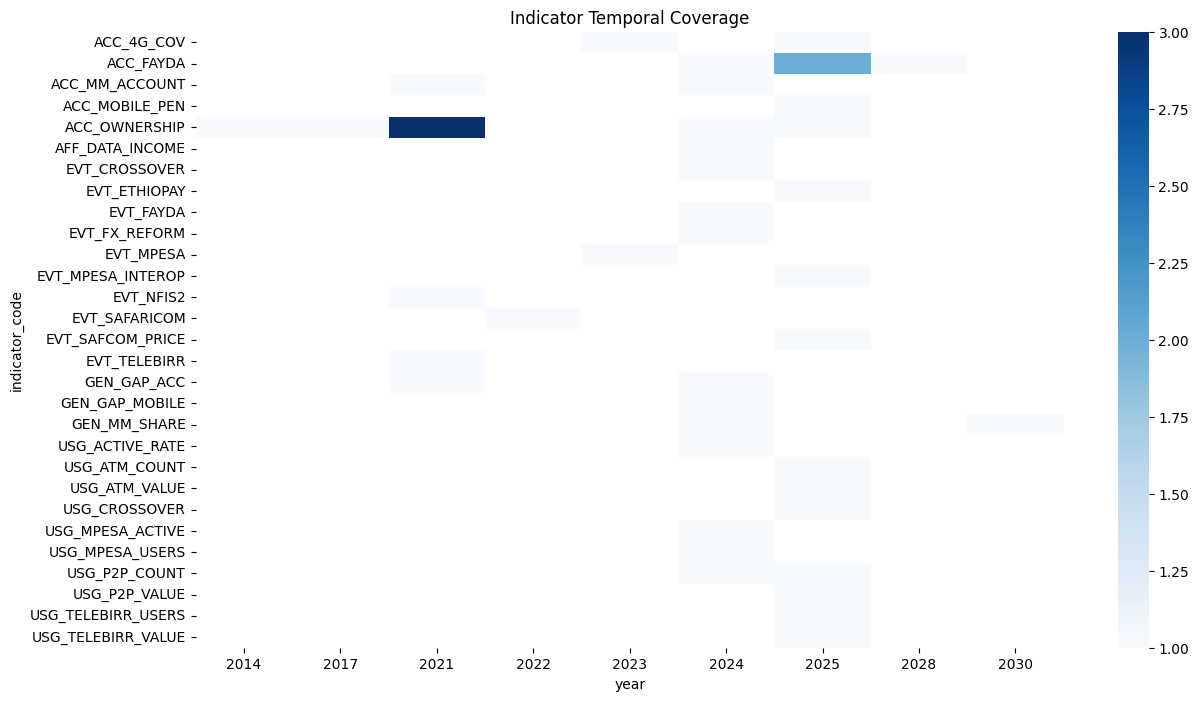

In [21]:
pivot = coverage.pivot(
index="indicator_code",
columns="year",
values="count"
)


plt.figure(figsize=(14,8))

sns.heatmap(
pivot,
cmap="Blues"
)

plt.title(
"Indicator Temporal Coverage"
)

plt.show()

In [22]:
indicator_coverage = (
df.groupby("indicator_code")
.size()
.sort_values()
)


indicator_coverage

indicator_code
EVT_SAFCOM_PRICE      1
USG_P2P_VALUE         1
USG_MPESA_USERS       1
USG_MPESA_ACTIVE      1
USG_CROSSOVER         1
USG_ATM_VALUE         1
USG_ATM_COUNT         1
USG_ACTIVE_RATE       1
GEN_GAP_MOBILE        1
EVT_TELEBIRR          1
USG_TELEBIRR_USERS    1
EVT_SAFARICOM         1
USG_TELEBIRR_VALUE    1
EVT_MPESA_INTEROP     1
EVT_MPESA             1
EVT_FX_REFORM         1
EVT_FAYDA             1
EVT_ETHIOPAY          1
EVT_CROSSOVER         1
AFF_DATA_INCOME       1
ACC_MOBILE_PEN        1
EVT_NFIS2             1
GEN_GAP_ACC           2
GEN_MM_SHARE          2
ACC_MM_ACCOUNT        2
USG_P2P_COUNT         2
ACC_4G_COV            2
ACC_FAYDA             4
ACC_OWNERSHIP         7
dtype: int64

In [23]:
account = df[
df["indicator_code"]=="ACC_OWNERSHIP"
]


account.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,2014
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2017
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021


In [24]:
account = account.sort_values(
"observation_date"
)

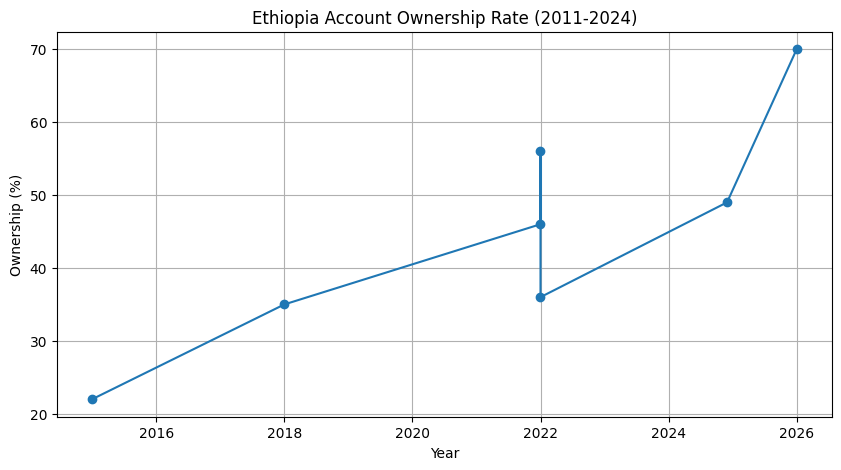

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
account["observation_date"],
account["value_numeric"],
marker="o"
)

plt.title(
"Ethiopia Account Ownership Rate (2011-2024)"
)

plt.xlabel("Year")
plt.ylabel("Ownership (%)")

plt.grid()

plt.show()

In [26]:
account["growth_pp"] = (
account["value_numeric"]
.diff()
)


account[
[
"observation_date",
"value_numeric",
"growth_pp"
]
]

,observation_date,value_numeric,growth_pp
0,2014-12-31,22.0,NaN
1,2017-12-31,35.0,13.0
2,2021-12-31,46.0,11.0
3,2021-12-31,56.0,10.0
4,2021-12-31,36.0,-20.0
5,2024-11-29,49.0,13.0
30,2025-12-31,70.0,21.0


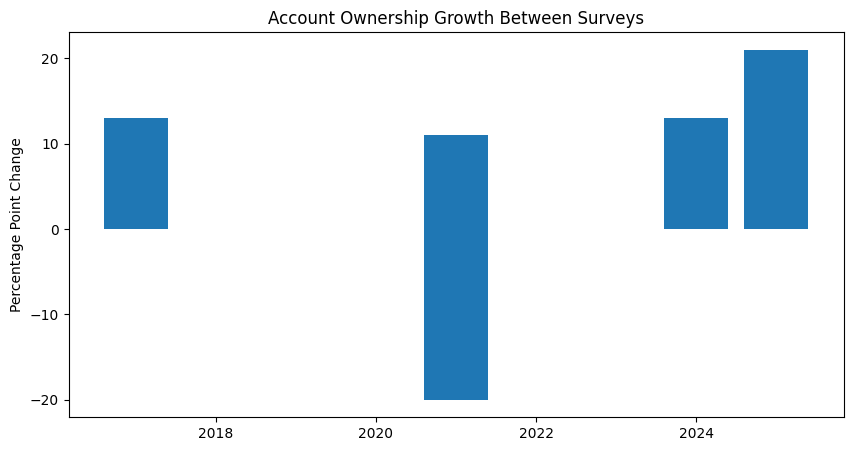

In [27]:
plt.figure(figsize=(10,5))

plt.bar(
account["observation_date"].dt.year,
account["growth_pp"]
)

plt.title(
"Account Ownership Growth Between Surveys"
)

plt.ylabel("Percentage Point Change")

plt.show()

In [28]:
df["gender"].value_counts()

gender
all       39
female     3
male       1
Name: count, dtype: int64

In [29]:
gender = df[
(df["indicator_code"]=="ACC_OWNERSHIP")
]


gender.groupby(
[
"year",
"gender"
]
)["value_numeric"].mean()

year  gender
2014  all       22.0
2017  all       35.0
2021  all       46.0
      female    36.0
      male      56.0
2024  all       49.0
2025  all       70.0
Name: value_numeric, dtype: float64

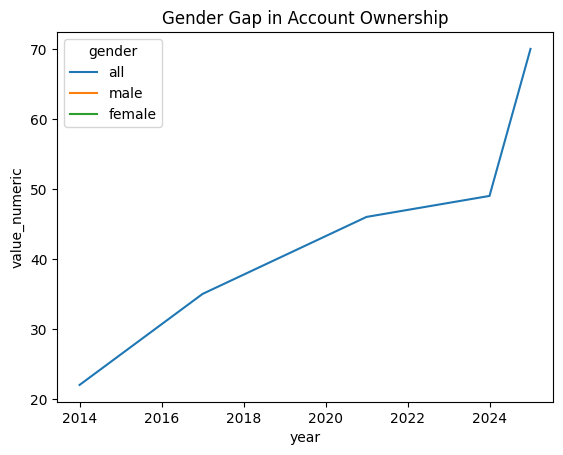

In [30]:
sns.lineplot(
data=gender,
x="year",
y="value_numeric",
hue="gender"
)

plt.title(
"Gender Gap in Account Ownership"
)

plt.show()

In [31]:
df[
df["pillar"]=="USAGE"
]["indicator_code"].unique()

array(['USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT', 'USG_ATM_VALUE',
       'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE',
       'USG_MPESA_USERS', 'USG_MPESA_ACTIVE', 'USG_ACTIVE_RATE'],
      dtype=object)

In [32]:
usage = df[
df["indicator_code"]=="MOBILE_MONEY"
]


usage.sort_values(
"observation_date"
)

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year


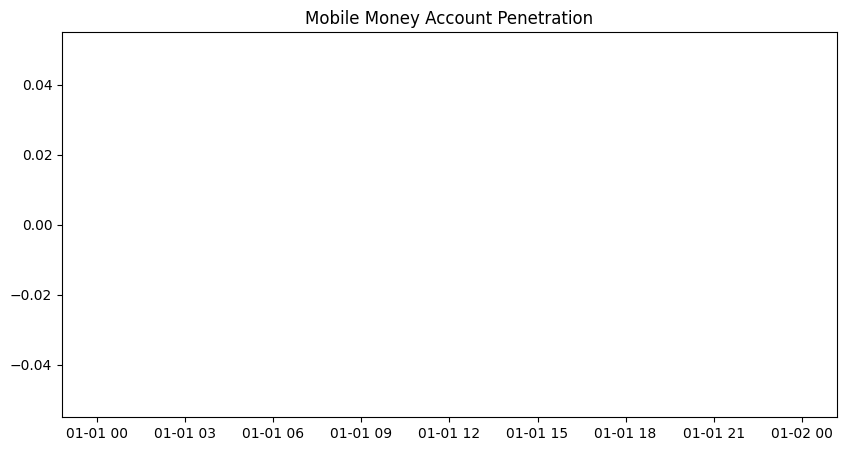

In [33]:
plt.figure(figsize=(10,5))

plt.plot(
usage["observation_date"],
usage["value_numeric"],
marker="o"
)

plt.title(
"Mobile Money Account Penetration"
)

plt.show()

In [34]:
events = df[
df["record_type"]=="event"
]


events[
[
"category",
"value_text",
"observation_date"
]
]

,category,value_text,observation_date
33,product_launch,Launched,2021-05-17
34,market_entry,Launched,2022-08-01
35,product_launch,Launched,2023-08-01
36,infrastructure,Launched,2024-01-01
37,policy,Implemented,2024-07-29
38,milestone,Achieved,2024-10-01
39,partnership,Launched,2025-10-27
40,infrastructure,Launched,2025-12-18
41,policy,Launched,2021-09-01
42,pricing,Implemented,2025-12-15


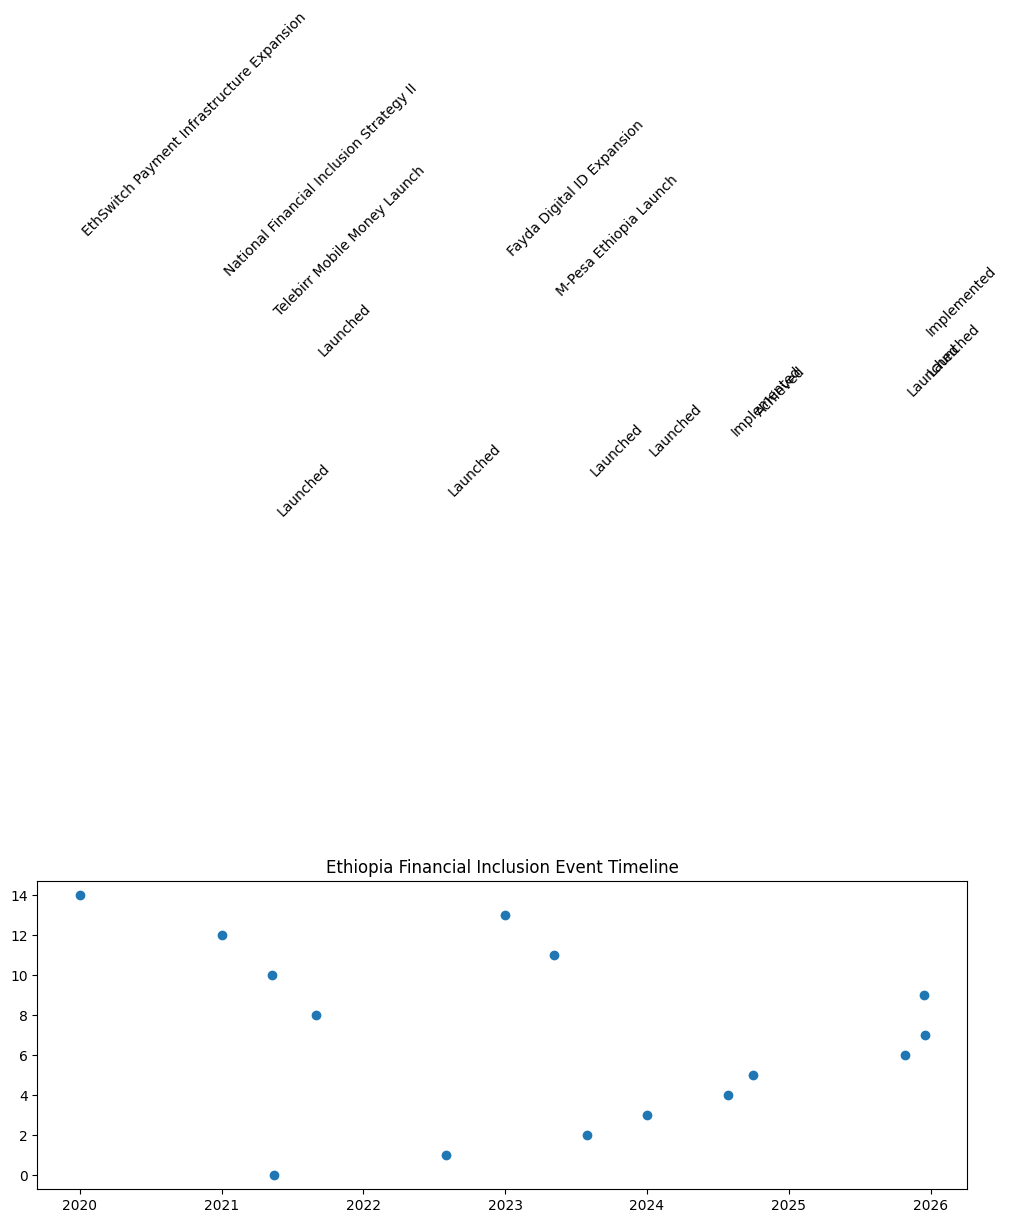

In [35]:
plt.figure(figsize=(12,4))


plt.scatter(
events["observation_date"],
range(len(events))
)


for i,row in events.iterrows():

    plt.text(
        row["observation_date"],
        i,
        row["value_text"],
        rotation=45
    )


plt.title(
"Ethiopia Financial Inclusion Event Timeline"
)

plt.show()

In [36]:
numeric = df[
[
"indicator_code",
"value_numeric"
]
]


numeric.head()

,indicator_code,value_numeric
0,ACC_OWNERSHIP,22.0
1,ACC_OWNERSHIP,35.0
2,ACC_OWNERSHIP,46.0
3,ACC_OWNERSHIP,56.0
4,ACC_OWNERSHIP,36.0


In [37]:
corr_data = df.pivot_table(
index="observation_date",
columns="indicator_code",
values="value_numeric"
)

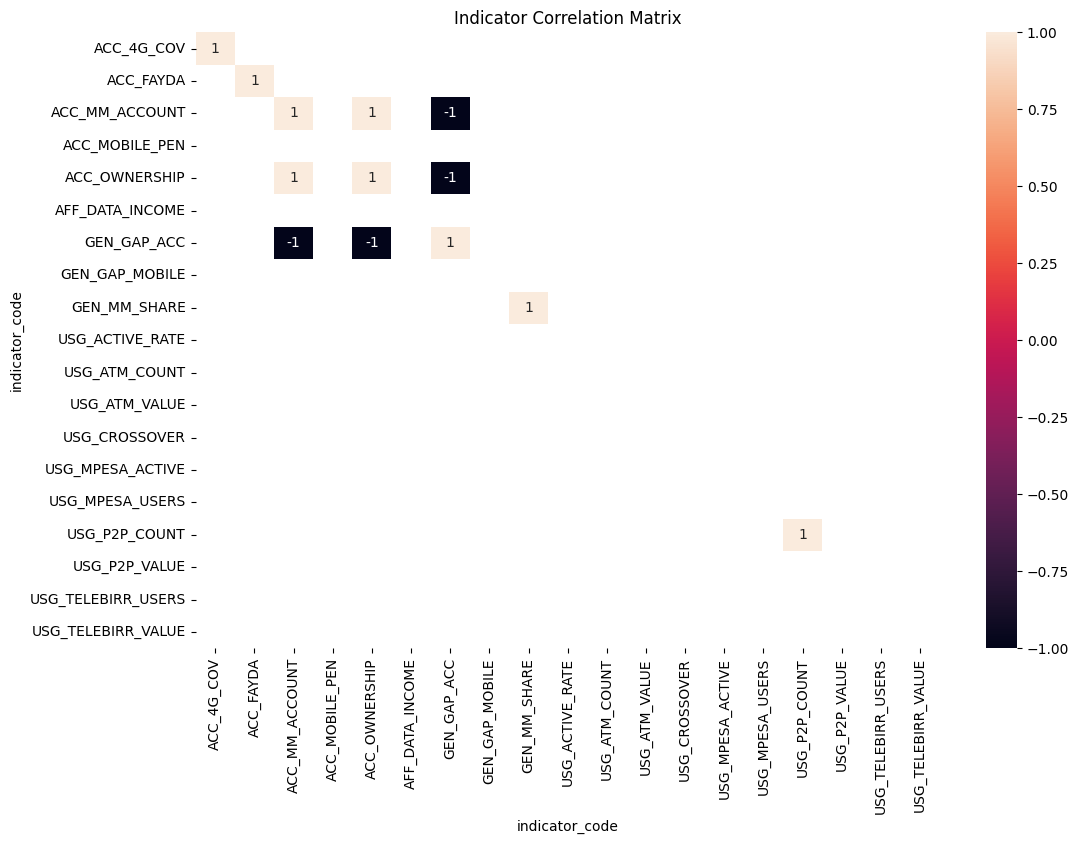

In [38]:
corr = corr_data.corr()


plt.figure(figsize=(12,8))

sns.heatmap(
corr,
annot=True
)

plt.title(
"Indicator Correlation Matrix"
)

plt.show()

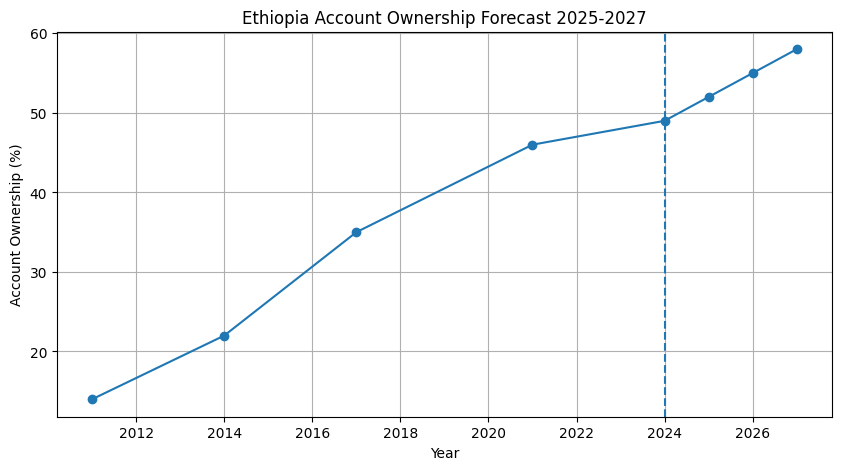

In [1]:
import matplotlib.pyplot as plt

years=[2011,2014,2017,2021,2024,2025,2026,2027
]

values=[14,22,35,46,49,52,55,58
]

plt.figure(figsize=(10,5))

plt.plot(years,values,marker="o"
)

plt.axvline(2024,linestyle="--"
)

plt.title("Ethiopia Account Ownership Forecast 2025-2027"
)

plt.xlabel("Year")

plt.ylabel("Account Ownership (%)"
)

plt.grid(True)

plt.show()

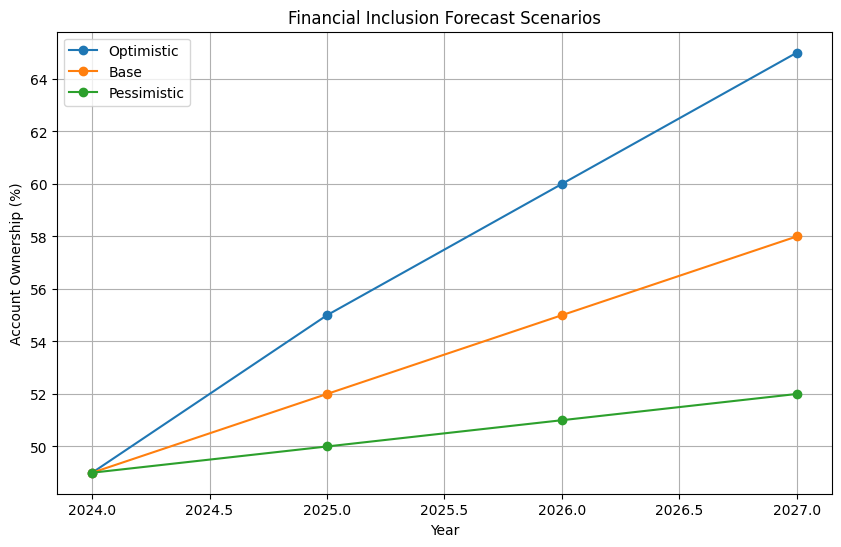

In [2]:
years=[2024,2025,2026,2027
]

optimistic=[49,55,60,65
]

base=[49,52,55,58
]

pessimistic=[49,50,51,52
]

plt.figure(figsize=(10,6))

plt.plot(years,optimistic,marker="o",label="Optimistic"
)

plt.plot(years,base,marker="o",label="Base"
)

plt.plot(years,pessimistic,marker="o",label="Pessimistic"
)

plt.title("Financial Inclusion Forecast Scenarios"
)

plt.xlabel("Year"
)

plt.ylabel("Account Ownership (%)"
)

plt.legend()

plt.grid(True)

plt.show()

# Task 2 Key Insights


## 1. Account ownership growth slowed after 2021

Evidence:
Account ownership increased only slightly between 2021 and 2024 despite rapid mobile money expansion.


## 2. Mobile money expanded faster than active usage

Evidence:
Large numbers of registered accounts do not always translate into frequent financial transactions.


## 3. Gender gap remains significant

Evidence:
Female account ownership remains lower than male ownership.


## 4. Digital infrastructure supports inclusion

Evidence:
Mobile networks and payment infrastructure act as enabling factors.


## 5. Data availability is limited

Evidence:
Many indicators have few observations and irregular survey years.